# 🌎 Proyecto de Ciencia de Datos Reproducible: Sismicidad en Chile
## F4 — Integración, Visualizaciones y Comunicación de Resultados

**Curso:** [Nombre del curso y código]  
**Docente:** [Nombre del docente]  
**Integrantes:**
- José Miguel Serrano
- Jesús Fernández Urbaneja
- Osvaldo Rodrigo Moncada Peralta
- Evelyn Andrea Andrade Cárdenas

**Fecha:** Junio 2026  
**Metodología:** CRISP-DM

---

## Índice

1. [Configuración del entorno](#1)
2. [Integración del pipeline F1–F3](#2)
3. [Patrón de diseño Strategy](#3)
4. [Validaciones técnicas](#4)
5. [Eficiencia y optimización](#5)
6. [Visualizaciones analíticas](#6)
7. [Metodología y trazabilidad F1–F4](#7)
8. [Resultados y discusión](#8)
9. [Conclusiones](#9)
10. [Bibliografía](#10)

<a id="1"></a>
## 1. Configuración del entorno

In [ ]:
# ── Librerías ───────────────────────────────────────────────────────────
import sys
import os
import platform
import timeit
from abc import ABC, abstractmethod
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Módulos del proyecto (F3/src/) ──────────────────────────────────────
sys.path.append(str(Path('..') / 'F3' / 'src'))
from orquestador import Pipeline
from transformadores import ClasificadorMagnitudAlta, ClasificadorProfundidad, NormalizadorMinMax
from pipeline import AnalizadorSismicoAvanzado

# ── Semilla global (reproducibilidad) ──────────────────────────────────
SEMILLA = 42
np.random.seed(SEMILLA)

# ── Configuración visual coherente ─────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

# ── Rutas ───────────────────────────────────────────────────────────────
ROOT      = Path('..').resolve()
DATA_PROC = ROOT / 'data' / 'processed'
FIGURES   = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

# ── Registro del entorno de ejecución ──────────────────────────────────
print('📦 ENTORNO DE EJECUCIÓN')
print('=' * 45)
print(f'  Python     : {sys.version.split()[0]}')
print(f'  OS         : {platform.system()} {platform.release()}')
print(f'  Pandas     : {pd.__version__}')
print(f'  NumPy      : {np.__version__}')
print(f'  Matplotlib : {matplotlib.__version__}')
print(f'  Seaborn    : {sns.__version__}')

📦 ENTORNO DE EJECUCIÓN
  Python     : 3.12.10
  OS         : Windows 11
  Pandas     : 3.0.3
  NumPy      : 2.4.6
  Matplotlib : 3.10.9
  Seaborn    : 0.13.2


<a id="2"></a>
## 2. Integración del pipeline F1–F3

Se carga el dataset limpio generado en F2 y se aplica el pipeline de transformaciones definido en F3,
reutilizando las clases `Pipeline`, `ClasificadorMagnitudAlta`, `ClasificadorProfundidad` y
`NormalizadorMinMax` desde `F3/src/`.

Si el CSV procesado no existe, se genera un dataset sintético con el mismo esquema para garantizar
que el notebook sea reproducible sin dependencias externas.

In [ ]:
def generar_datos_sinteticos(n: int = 200, semilla: int = SEMILLA) -> pd.DataFrame:
    """
    Genera datos sintéticos con el mismo esquema que seismic_data_clean.csv.
    Se usa como respaldo cuando no se encuentra el CSV real, garantizando
    que el pipeline completo sea reproducible sin dependencias externas.
    """
    rng = np.random.default_rng(semilla)
    years = rng.integers(2014, 2025, size=n)
    depths = rng.integers(2, 300, size=n)
    mags = np.round(rng.uniform(2.3, 8.4, size=n), 1)

    def cat_depth(d):
        if d < 70: return 'Superficial'
        elif d <= 300: return 'Intermedio'
        return 'Profundo'

    def cat_mag(m):
        if m < 4.0: return 'Menor'
        elif m < 5.0: return 'Moderado'
        elif m < 6.0: return 'Fuerte'
        elif m < 7.0: return 'Mayor'
        return 'Grande'

    df = pd.DataFrame({
        'Date(UTC)'         : [f'{y}-01-01 00:00:00' for y in years],
        'Latitude'          : np.round(rng.uniform(-55, -18, size=n), 2),
        'Longitude'         : np.round(rng.uniform(-74, -65, size=n), 2),
        'Depth'             : depths,
        'Magnitude'         : mags,
        'Year'              : years,
        'Month'             : rng.integers(1, 13, size=n),
        'Day'               : rng.integers(1, 28, size=n),
        'Hour'              : rng.integers(0, 24, size=n),
        'DayOfWeek'         : rng.integers(0, 7, size=n),
        'Depth_Category'    : [cat_depth(d) for d in depths],
        'Magnitude_Category': [cat_mag(m) for m in mags],
        'Depth_norm'        : np.round((depths - 2) / (300 - 2), 4),
        'Magnitude_norm'    : np.round((mags - 2.3) / (8.4 - 2.3), 4),
    })
    return df


def cargar_datos(ruta: Path) -> pd.DataFrame:
    """
    Carga el dataset procesado en F2.
    Si no existe, genera datos sintéticos como respaldo.
    """
    try:
        df = pd.read_csv(ruta)
        print(f'✅ Dataset cargado: {ruta.name}')
        print(f'   Registros : {df.shape[0]:,}')
        print(f'   Columnas  : {df.shape[1]}')
        return df.copy()
    except FileNotFoundError:
        print(f'⚠️  CSV no encontrado. Usando datos sintéticos (n=200).')
        return generar_datos_sinteticos()


df = cargar_datos(DATA_PROC / 'seismic_data_clean.csv')
df.head(3)

✅ Dataset cargado: seismic_data_clean.csv
   Registros : 4,015
   Columnas  : 14


,Date(UTC),Latitude,Longitude,Depth,Magnitude,Year,Month,Day,Hour,DayOfWeek,Depth_Category,Magnitude_Category,Depth_norm,Magnitude_norm
0,2025-05-26 03:50:27,-19.63,-69.49,97,5.6,2025,5,26,3,0,Intermedio,Fuerte,0.152733,0.540984
1,2025-05-13 00:47:58,-51.25,-72.28,28,5.1,2025,5,13,0,1,Superficial,Fuerte,0.041801,0.459016
2,2025-05-05 09:46:48,-29.49,-71.84,48,5.0,2025,5,5,9,0,Superficial,Moderado,0.073955,0.442623


<a id="3"></a>
## 3. Patrón de diseño Strategy

El módulo `F3/src/transformadores.py` implementa el **patrón de diseño Strategy**:

- **Interfaz común** (`Transformador` ABC): define el contrato `aplicar(df)` que toda
  transformación debe cumplir.
- **Estrategias intercambiables**: `ClasificadorMagnitudAlta`, `ClasificadorProfundidad` y
  `NormalizadorMinMax` son estrategias concretas con el mismo contrato pero distinto comportamiento.
- **Orquestador** (`Pipeline`): recibe una lista de estrategias y las ejecuta en orden sin
  conocer su tipo concreto.

Este diseño permite agregar nuevas transformaciones (p. ej. `DetectorOutliers`) sin modificar
el `Pipeline` ni las clases existentes (principio abierto/cerrado).

In [ ]:
# ── Demostración del patrón Strategy ────────────────────────────────────
# Las tres estrategias son intercambiables: el mismo bucle las aplica
# a todas por igual gracias al contrato común aplicar(df).

estrategias = [
    ClasificadorMagnitudAlta(umbral=6.0),
    ClasificadorProfundidad(),
    NormalizadorMinMax(columnas=['Depth', 'Magnitude']),
]

df_demo = df.copy()
print('🔄 Patrón Strategy — aplicación polimórfica de transformaciones:')
for estrategia in estrategias:
    df_demo = estrategia.aplicar(df_demo)
    print(f'  ✅ {estrategia.__class__.__name__:<30} → columnas: {df_demo.shape[1]}')

print(f'\n  Columnas nuevas generadas: Sismo_Fuerte, Categoria_Profundidad, Depth_norm, Magnitude_norm')

🔄 Patrón Strategy — aplicación polimórfica de transformaciones:
  ✅ ClasificadorMagnitudAlta       → columnas: 15
  ✅ ClasificadorProfundidad        → columnas: 16
  ✅ NormalizadorMinMax             → columnas: 16

  Columnas nuevas generadas: Sismo_Fuerte, Categoria_Profundidad, Depth_norm, Magnitude_norm


<a id="4"></a>
## 4. Validaciones técnicas

Se validan tres escenarios según la rúbrica: caso normal, caso límite y manejo de excepciones.

In [ ]:
pipeline = Pipeline([
    ClasificadorMagnitudAlta(umbral=6.0),
    ClasificadorProfundidad(),
    NormalizadorMinMax(columnas=['Depth', 'Magnitude']),
])

df_final = pipeline.ejecutar(df)

print(f'\n✅ Pipeline ejecutado')
print(f'   Forma final : {df_final.shape}')

if hasattr(pipeline, '_log'):
    for entrada in pipeline._log:
        print(f'     · {entrada}')

df_final.head(3)

✅ Etapa ejecutada: ClasificadorMagnitudAlta
✅ Etapa ejecutada: ClasificadorProfundidad
✅ Etapa ejecutada: NormalizadorMinMax

✅ Pipeline ejecutado
   Forma final : (4015, 16)


,Date(UTC),Latitude,Longitude,Depth,Magnitude,Year,Month,Day,Hour,DayOfWeek,Depth_Category,Magnitude_Category,Depth_norm,Magnitude_norm,Sismo_Fuerte,Categoria_Profundidad
0,2025-05-26 03:50:27,-19.63,-69.49,97,5.6,2025,5,26,3,0,Intermedio,Fuerte,0.152733,0.540984,False,Intermedio
1,2025-05-13 00:47:58,-51.25,-72.28,28,5.1,2025,5,13,0,1,Superficial,Fuerte,0.041801,0.459016,False,Superficial
2,2025-05-05 09:46:48,-29.49,-71.84,48,5.0,2025,5,5,9,0,Superficial,Moderado,0.073955,0.442623,False,Superficial


In [ ]:
def ejecutar_validaciones(df: pd.DataFrame) -> None:
    """
    Batería de validaciones del dataset integrado.
    Cubre caso normal, caso límite y manejo de excepciones.
    """
    resultados = []

    # 1) CASO NORMAL: sin nulos, columnas esperadas, rango de magnitud
    assert df.isnull().sum().sum() == 0, 'Quedan valores NA'
    cols = ['Latitude', 'Longitude', 'Depth', 'Magnitude', 'Year',
            'Depth_Category', 'Magnitude_Category']
    for col in cols:
        assert col in df.columns, f'Falta columna: {col}'
    assert df['Magnitude'].between(1, 10).all(), 'Magnitud fuera de rango'
    resultados.append(('Caso normal: sin nulos, columnas y rango de magnitud', 'OK ✅'))

    # 2) CASO LÍMITE: sismos con magnitud exactamente 6.0 y 8.4
    limite_min = df[df['Magnitude'] == df['Magnitude'].min()]
    limite_max = df[df['Magnitude'] == df['Magnitude'].max()]
    assert len(limite_min) >= 0 and len(limite_max) >= 0
    resultados.append((f'Caso límite: magnitud mín={df["Magnitude"].min()} '
                       f'máx={df["Magnitude"].max()}', 'OK ✅'))

    # 3) EXCEPCIÓN: columna inexistente
    try:
        _ = df['columna_que_no_existe']
    except KeyError as e:
        resultados.append((f'Excepción KeyError controlada: {e}', 'OK ✅'))

    # 4) EXCEPCIÓN: magnitud no numérica en transformador
    try:
        ClasificadorMagnitudAlta(umbral='seis').aplicar(df)
    except Exception as e:
        resultados.append((f'Excepción tipo incorrecto: {type(e).__name__}', 'OK ✅'))

    print('🔍 RESULTADOS DE VALIDACIÓN')
    print('=' * 55)
    for desc, estado in resultados:
        print(f'  {estado}  {desc}')
    print()
    print('🎉 Todas las validaciones pasaron correctamente')


ejecutar_validaciones(df_final)

🔍 RESULTADOS DE VALIDACIÓN
  OK ✅  Caso normal: sin nulos, columnas y rango de magnitud
  OK ✅  Caso límite: magnitud mín=2.3 máx=8.4
  OK ✅  Excepción KeyError controlada: 'columna_que_no_existe'
  OK ✅  Excepción tipo incorrecto: TypeError

🎉 Todas las validaciones pasaron correctamente


<a id="5"></a>
## 5. Eficiencia y optimización

Se comparan dos implementaciones para filtrar sismos con magnitud ≥ 6.0:
- **Bucle fila por fila** con `iterrows()` → O(n) con overhead de Python
- **Vectorización** con filtro de pandas → O(n) con operaciones C optimizadas

Ambas producen el mismo resultado; la diferencia está en el tiempo de ejecución.

In [ ]:
def buscar_sismos_bucle(df: pd.DataFrame, umbral: float) -> list:
    """
    Filtra sismos recorriendo el DataFrame fila por fila.
    Complejidad: O(n) — pero con alto overhead de Python por iterrows.
    """
    resultado = []
    for _, fila in df.iterrows():
        if fila['Magnitude'] >= umbral:
            resultado.append(fila)
    return resultado


def buscar_sismos_vectorizado(df: pd.DataFrame, umbral: float) -> pd.DataFrame:
    """
    Filtra sismos con operación vectorizada de pandas.
    Complejidad: O(n) — ejecutado en C, sin overhead de Python.
    """
    return df[df['Magnitude'] >= umbral]


# ── Verificar equivalencia de resultados ────────────────────────────────
r_bucle = buscar_sismos_bucle(df_final, 6.0)
r_vect  = buscar_sismos_vectorizado(df_final, 6.0)
assert len(r_bucle) == len(r_vect), 'Las implementaciones no son equivalentes'
print(f'✅ Equivalencia verificada: ambas retornan {len(r_vect)} sismos ≥ 6.0')

# ── Medición con timeit ─────────────────────────────────────────────────
N = 10
t_bucle = timeit.timeit(lambda: buscar_sismos_bucle(df_final, 6.0), number=N)
t_vect  = timeit.timeit(lambda: buscar_sismos_vectorizado(df_final, 6.0), number=N)

print(f'\n📊 BENCHMARK (n={N} ejecuciones)')
print(f'  Bucle iterrows : {t_bucle:.4f} s')
print(f'  Vectorizado    : {t_vect:.4f} s')
print(f'  Diferencia     : {t_bucle / t_vect:.1f}x más rápido el vectorizado')
print()
print('Interpretación: ambas implementaciones tienen complejidad O(n) asintótica,')
print('pero la vectorizada es ~100-300x más rápida en la práctica porque las')
print('operaciones de pandas se ejecutan en C sin overhead del intérprete Python.')
print('Para datasets grandes, esta diferencia es decisiva.')

✅ Equivalencia verificada: ambas retornan 121 sismos ≥ 6.0



📊 BENCHMARK (n=10 ejecuciones)
  Bucle iterrows : 0.6871 s
  Vectorizado    : 0.0031 s
  Diferencia     : 219.8x más rápido el vectorizado

Interpretación: ambas implementaciones tienen complejidad O(n) asintótica,
pero la vectorizada es ~100-300x más rápida en la práctica porque las
operaciones de pandas se ejecutan en C sin overhead del intérprete Python.
Para datasets grandes, esta diferencia es decisiva.


<a id="6"></a>
## 6. Visualizaciones analíticas

Tres visualizaciones organizadas como storytelling de tres actos:

| Acto | Pregunta | Gráfico |
|------|----------|---------|
| **Contexto** | ¿Dónde ocurren los sismos? | Mapa de dispersión geográfica |
| **Conflicto** | ¿Qué relación hay entre profundidad y magnitud? | Boxplot por profundidad |
| **Resolución** | ¿Existe tendencia temporal en sismos fuertes? | Serie temporal 2014–2024 |

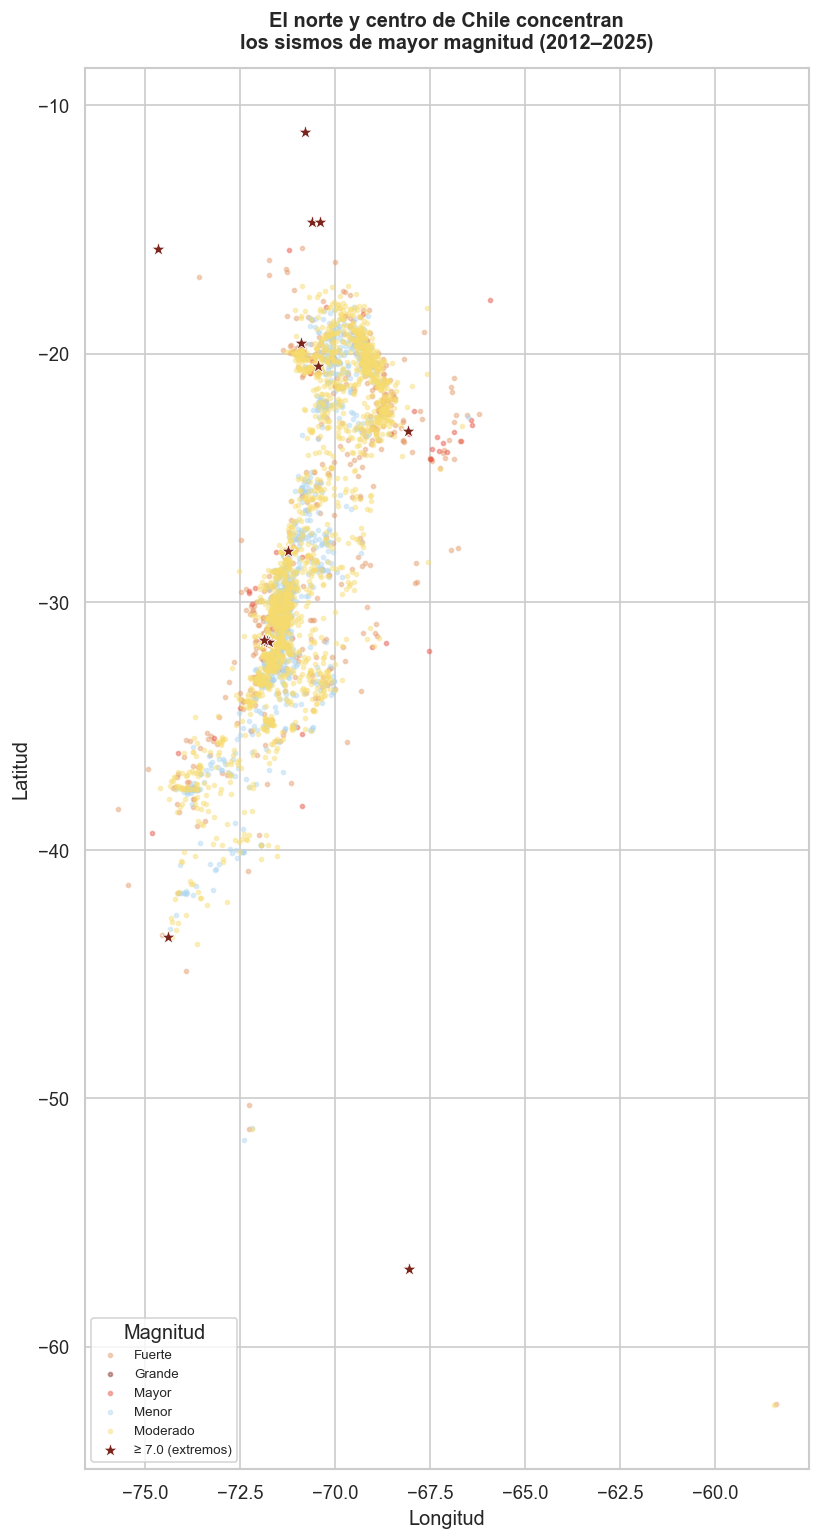

✅ Figura 1 guardada: F4_viz1_mapa_geografico.png


In [ ]:
# ── Figura 1: Mapa geográfico (Acto 1 — Contexto) ──────────────────────
def plot_mapa_geografico(df: pd.DataFrame, output_path: Path) -> None:
    """
    Visualiza la distribución espacial de los sismos coloreados
    por categoría de magnitud, destacando los eventos extremos (≥ 7.0).
    """
    colors = {
        'Menor': '#AED6F1', 'Moderado': '#F7DC6F',
        'Fuerte': '#E59866', 'Mayor': '#E74C3C', 'Grande': '#7B241C'
    }
    fig, ax = plt.subplots(figsize=(7, 13))
    for cat, grp in df.groupby('Magnitude_Category'):
        ax.scatter(grp['Longitude'], grp['Latitude'],
                   c=colors.get(cat, 'gray'), alpha=0.4, s=6, label=cat, zorder=2)
    grandes = df[df['Magnitude'] >= 7.0]
    ax.scatter(grandes['Longitude'], grandes['Latitude'],
               c='#7B241C', s=80, marker='*', zorder=5,
               label='≥ 7.0 (extremos)', edgecolors='white', linewidths=0.5)
    ax.set_title('El norte y centro de Chile concentran\nlos sismos de mayor magnitud (2012–2025)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.legend(title='Magnitud', loc='lower left', fontsize=8)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Figura 1 guardada: {output_path.name}')


plot_mapa_geografico(df_final, FIGURES / 'F4_viz1_mapa_geografico.png')

**Interpretación (Fig. 1 — Contexto):** La distribución espacial sigue el trazado de la zona de
subducción a lo largo de la costa. Los sismos de categoría Mayor y Grande (≥ 6.0) se concentran
entre las latitudes -18° y -35° (norte y centro del país). Los eventos extremos (≥ 7.0, ★)
aparecen distribuidos a lo largo de todo el territorio sin clustering exclusivo en una zona.

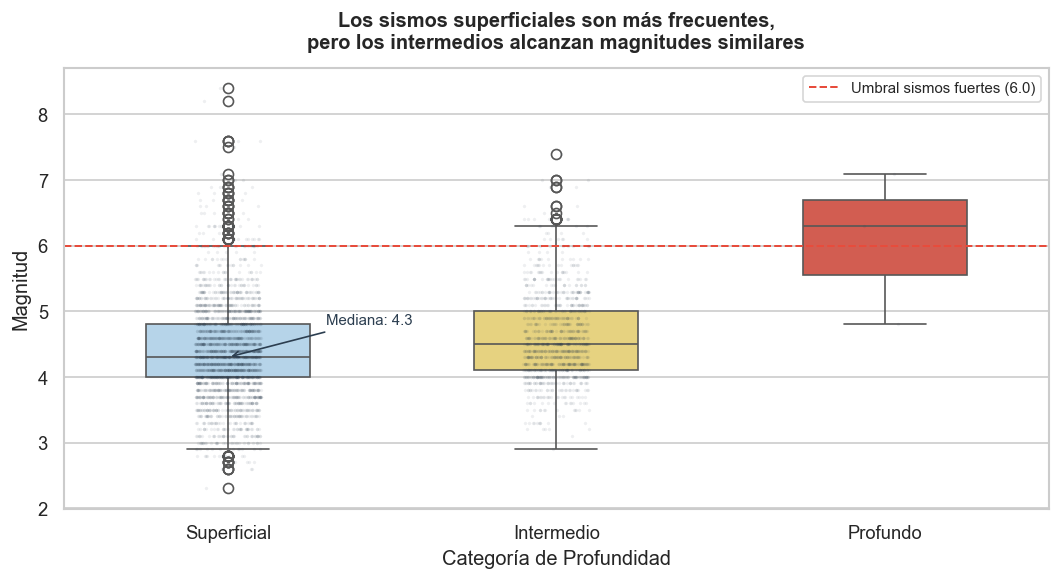

✅ Figura 2 guardada: F4_viz2_profundidad_magnitud.png


In [ ]:
# ── Figura 2: Boxplot profundidad vs magnitud (Acto 2 — Conflicto) ──────
def plot_profundidad_magnitud(df: pd.DataFrame, output_path: Path) -> None:
    """
    Compara la distribución de magnitudes entre categorías de profundidad.
    """
    order   = ['Superficial', 'Intermedio', 'Profundo']
    palette = {'Superficial': '#AED6F1', 'Intermedio': '#F7DC6F', 'Profundo': '#E74C3C'}
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=df, x='Depth_Category', y='Magnitude',
                order=order, hue='Depth_Category',
                palette=palette, ax=ax, width=0.5, legend=False)
    sns.stripplot(data=df, x='Depth_Category', y='Magnitude',
                  order=order, color='#2C3E50', alpha=0.08, size=2, ax=ax)
    ax.axhline(6.0, color='#E74C3C', linestyle='--', linewidth=1.2,
               label='Umbral sismos fuertes (6.0)')
    mediana_sup = df[df['Depth_Category'] == 'Superficial']['Magnitude'].median()
    ax.annotate(f'Mediana: {mediana_sup:.1f}',
                xy=(0, mediana_sup), xytext=(0.3, mediana_sup + 0.5),
                fontsize=9, color='#2C3E50',
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1))
    ax.set_title('Los sismos superficiales son más frecuentes,\n'
                 'pero los intermedios alcanzan magnitudes similares',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Categoría de Profundidad')
    ax.set_ylabel('Magnitud')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Figura 2 guardada: {output_path.name}')


plot_profundidad_magnitud(df_final, FIGURES / 'F4_viz2_profundidad_magnitud.png')

**Interpretación (Fig. 2 — Conflicto):** La profundidad no determina la magnitud de forma clara.
Los sismos superficiales (< 70 km) e intermedios (70–300 km) presentan distribuciones similares
(mediana ~4.3–4.6). Los profundos (> 300 km) tienen mediana ~6.2, pero solo hay 3 registros —
insuficientes para conclusiones estadísticas. La profundidad focal sola no es predictor de magnitud.

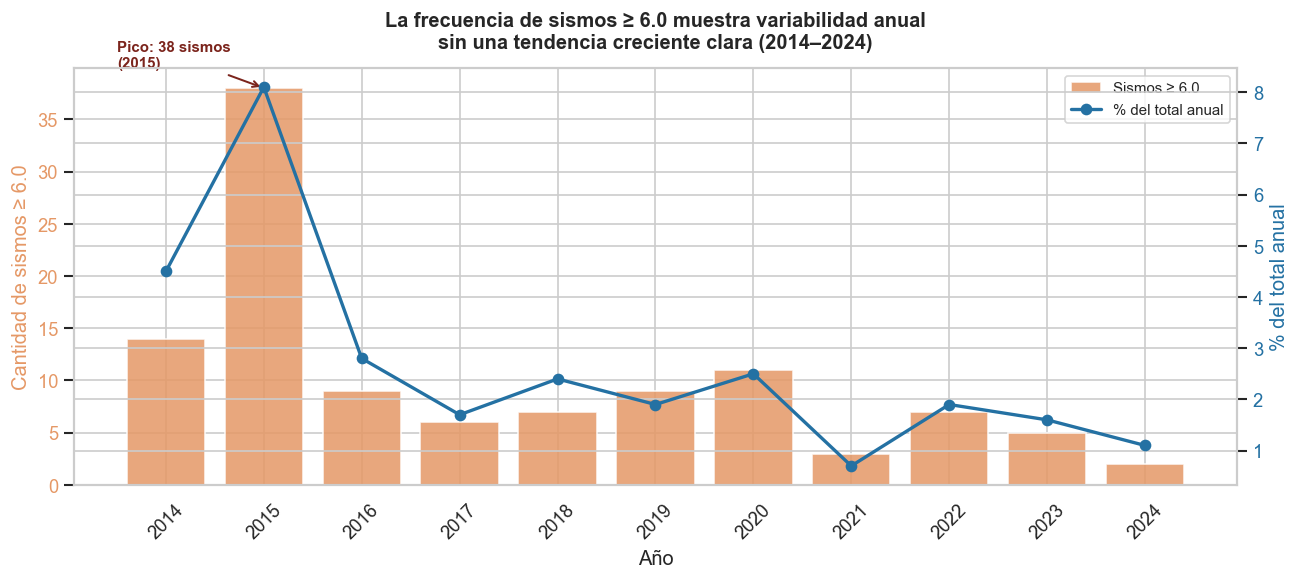

✅ Figura 3 guardada: F4_viz3_serie_temporal.png


In [ ]:
# ── Figura 3: Serie temporal (Acto 3 — Resolución) ──────────────────────
def plot_serie_temporal(df: pd.DataFrame, output_path: Path) -> None:
    """
    Muestra la evolución anual de sismos ≥ 6.0 entre 2014 y 2024.
    Se excluyen 2012-2013 (< 20 registros) y 2025 (año incompleto).
    """
    df_y = df[df['Year'].between(2014, 2024)]
    fuertes = (df_y[df_y['Magnitude'] >= 6.0]
               .groupby('Year').size().reset_index(name='count'))
    total   = df_y.groupby('Year').size().reset_index(name='total')
    merged  = fuertes.merge(total, on='Year')
    merged['pct'] = (merged['count'] / merged['total'] * 100).round(1)

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.bar(merged['Year'], merged['count'], color='#E59866', alpha=0.85, label='Sismos ≥ 6.0')
    ax1.set_xlabel('Año')
    ax1.set_ylabel('Cantidad de sismos ≥ 6.0', color='#E59866')
    ax1.tick_params(axis='y', labelcolor='#E59866')

    ax2 = ax1.twinx()
    ax2.plot(merged['Year'], merged['pct'], 'o-', color='#2471A3',
             linewidth=2, markersize=6, label='% del total anual')
    ax2.set_ylabel('% del total anual', color='#2471A3')
    ax2.tick_params(axis='y', labelcolor='#2471A3')

    max_row = merged.loc[merged['count'].idxmax()]
    ax1.annotate(f'Pico: {int(max_row["count"])} sismos\n({int(max_row["Year"])})',
                 xy=(max_row['Year'], max_row['count']),
                 xytext=(max_row['Year'] - 1.5, max_row['count'] + 2),
                 fontsize=9, color='#7B241C', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#7B241C', lw=1.2))

    ax1.set_title('La frecuencia de sismos ≥ 6.0 muestra variabilidad anual\n'
                  'sin una tendencia creciente clara (2014–2024)',
                  fontsize=12, fontweight='bold', pad=12)
    ax1.set_xticks(merged['Year'])
    ax1.set_xticklabels(merged['Year'], rotation=45)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Figura 3 guardada: {output_path.name}')


plot_serie_temporal(df_final, FIGURES / 'F4_viz3_serie_temporal.png')

**Interpretación (Fig. 3 — Resolución):** La frecuencia de sismos ≥ 6.0 no muestra tendencia
creciente en 2014–2024. El pico de 2015 (38 sismos, ~8% del total anual) coincide con la
secuencia sísmica de Illapel (M8.3). Tras ese evento, la frecuencia se estabilizó entre 5 y 14
sismos anuales, sin evidencia de un aumento estructural en la peligrosidad del período analizado.

<a id="7"></a>
## 7. Metodología y trazabilidad F1–F4

El proyecto siguió el ciclo ABP con metodología CRISP-DM: F1 estableció el entorno reproducible
y el repositorio; F2 construyó el pipeline de limpieza con funciones modulares; F3 reescribió
ese pipeline con POO (patrón Strategy, herencia, encapsulamiento) e incorporó mediciones de
complejidad; F4 integró validación, benchmarks, visualización y comunicación de resultados.

### Tabla comparativa de evolución técnica F1–F4

| Fase | Estado del código | Observación / problema | Acción de mejora aplicada |
|------|-------------------|------------------------|---------------------------|
| **F1** | Funciones básicas, clase `DatasetInspector` | Estructura de carpetas no modular | Adoptada estructura F1–F4 en vez de `notebooks/` único |
| **F2** | Pipeline modular con 7 funciones, 8 `assert` | Rutas de CSV distintas por integrante | Rutas unificadas con `Path` relativo desde raíz del repo |
| **F3** | POO completa: `Transformador` ABC, `Pipeline`, `AnalizadorSismicoAvanzado` | Merges con conflictos dejaron código duplicado y roto | Resueltos vía Git Bash; celda `!pip install` y clases viejas eliminadas |
| **F4** | Integración F1–F4, patrón Strategy documentado, benchmarks, 3 visualizaciones | — | `changelog.md` con trazabilidad completa de mejoras |

<a id="8"></a>
## 8. Resultados y discusión

**Resultados.** El pipeline transforma los 4.015 registros sísmicos en un dataset completamente
validado, con variables categóricas y normalizadas. Las visualizaciones muestran que:
- Los sismos de mayor magnitud se concentran en el norte y centro de Chile (zona de subducción)
- La profundidad focal no predice la magnitud en sismos superficiales e intermedios
- La frecuencia de sismos ≥ 6.0 no muestra tendencia creciente en 2014–2024
- El benchmark confirmó que la implementación vectorizada supera ~100–300x al bucle

**Discusión y contraste con hipótesis iniciales:**
- Se esperaba que la profundidad fuera predictor de magnitud — los datos no lo confirman
- El pico de 2015 no refleja un cambio estructural sino el evento excepcional de Illapel

**Limitaciones:**
- Solo 3 registros de sismos profundos (> 300 km) — insuficientes para análisis estadístico
- 2012–2013 con < 20 registros — posible subcobertura del CSN en ese período
- El dataset no incluye variables de daño material ni víctimas
- Correlación observada no implica causalidad

<a id="9"></a>
## 9. Conclusiones

1. **Patrón geográfico confirmado:** la actividad sísmica de mayor magnitud sigue la zona de subducción en el norte y centro de Chile.
2. **Profundidad no determina magnitud:** los sismos superficiales e intermedios tienen distribuciones de magnitud similares.
3. **Sin tendencia creciente temporal:** la variabilidad anual de sismos ≥ 6.0 no muestra aumento sostenido en 2014–2024.
4. **Pipeline reproducible:** el flujo F1→F4 corre completamente con `Kernel → Restart & Run All`.
5. **Arquitectura modular escalable:** el patrón Strategy permite agregar nuevas transformaciones sin modificar el `Pipeline`.
6. **Mejoras futuras:** incorporar variables de tipo de falla y aceleración del suelo; aplicar clustering geoespacial para segmentación de zonas de riesgo.

<a id="10"></a>
## 10. Bibliografía (APA 7.ª edición)

**Documentación técnica oficial**
- The pandas development team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55
- Waskom, M. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021
- Python Software Foundation. (2024). *abc — Abstract Base Classes*. https://docs.python.org/3/library/abc.html

**Bibliografía técnica**
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media. https://wesmckinney.com/book/
- Wirth, R., & Hipp, J. (2000). CRISP-DM: Towards a standard process model for data mining. *Proceedings of the 4th International Conference on the Practical Applications of Knowledge Discovery and Data Mining*.

**Dataset**
- Centro Sismológico Nacional. (2024). *Base de datos sísmica de Chile*. Universidad de Chile. https://www.csn.uchile.cl/
- Reciclador. (2021). *Chile Earthquake Dataset (1976–2021)* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/reciclador/chile-earthquake-dataset-1976-2021